In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from IPython.core.display import display, HTML
from matplotlib import pyplot as plt
from matplotlib import ticker as mpl_ticker
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmxu0kd
interpreter: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
notebook name: 2025-12-14-external-selfbb-truebb-all
notebook path: /home/runner/work/oee4/oee4/binder/2025-12-14-external-selfbb-truebb-all.ipynb
revision: bdac574
timestamp: 2026-01-26T14:44:02Z00:00

IPython==7.16.1
packaging==25.0


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-12-14-external-selfbb-truebb-all"


In [5]:
df_all = []
for what, prefix in [
    ("nobb", "endeavor=16/external-competitions/stage=2+what=collated/"),
    ("selfbb", "endeavor=16/external-competitions-focalbb/stage=2+what=collated/"),
    ("truebb", "endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/"),
]:
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket("prq49")


    competitions = bucket_handle.objects.filter(Prefix=prefix)
    dfs = [
        pd.read_csv(
          f's3://prq49/{competitions.key}',
        )
        for competitions in competitions
    ]
    print(len(dfs))
    df = pd.concat(dfs, ignore_index=True)
    df["kind"] = what

    df_all.append(df)

df = pd.concat(df_all, ignore_index=True)


100
100
99


In [6]:
df


,Competition Stint,Competition Series,Competition Replicate,Competition Treatment,Treatment _,Treatment mut_sever,Treatment mut_freq,Treatment diversity,Treatment bucket,Competition Endeavor,...,genome proc,genome root_id,genome series,genome stint,genome thread,genome variation,kind,genome dose,genome filter_lowest_root,genome filter_except_lowest_root
0,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,0,16005,1,0,master,nobb,NaN,NaN,NaN
1,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,1,16000,1,0,master,nobb,NaN,NaN,NaN
2,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,0,16005,1,0,master,nobb,NaN,NaN,NaN
3,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,1,16001,1,0,master,nobb,NaN,NaN,NaN
4,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,0,16005,1,0,master,nobb,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321021,99,16005,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,0,16005,99,0,master,truebb,NaN,NaN,NaN
321022,99,16005,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,2,16005,99,0,master,truebb,2.0,NaN,NaN
321023,99,16005,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,1,16025,99,0,master,truebb,NaN,NaN,NaN
321024,99,16005,1,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,0,0,16005,99,0,master,truebb,NaN,NaN,NaN


teeplots/2025-12-14-external-selfbb-truebb-all/col=competition-series+hue=kind1+kind=line+marker=o+style=kind1+viz=relplot+x=competition-stint+y=focal-prevalence+ext=.pdf
teeplots/2025-12-14-external-selfbb-truebb-all/col=competition-series+hue=kind1+kind=line+marker=o+style=kind1+viz=relplot+x=competition-stint+y=focal-prevalence+ext=.png


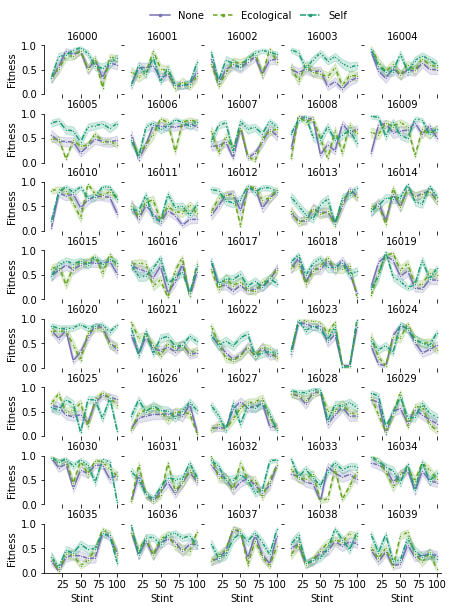

In [7]:
palette = [
    sns.color_palette("Dark2")[2],
    sns.color_palette("Dark2")[4],
    sns.color_palette("Dark2")[0],
]

dfx = df.loc[
    (df["Root ID"] == 0),
    [
        "Competition Stint",
        "Focal Prevalence",
        "kind",
        "Competition Series",
        "genome series",
    ]
]

dfx["kind1"] = dfx["kind"].map({
    "nobb": "None",
    "selfbb": "Self",
    "truebb": "Ecological",
})

data = dfx[
    dfx["Competition Stint"].isin(range(10, 101, 10))
]

with tp.teed(
    sns.relplot,
    data=data,
    x="Competition Stint",
    y="Focal Prevalence",
    hue="kind1",
    hue_order=["None", "Ecological", "Self"],
    style="kind1",
    col="Competition Series",
    col_wrap=5,
    dashes=["", (4, 1, 1, 1), (3, 2)],
    kind="line",
    marker="o",
    markersize=2.5,
    palette=palette,
    teeplot_subdir=teeplot_subdir,
) as g:
    g.figure.set_size_inches(6, 7.5)
    g.set_titles(col_template="{col_name}")
    g.set_ylabels("Fitness")
    g.set(xlim=(0, 105), ylim=(0, 1))
    g.fig.subplots_adjust(hspace=0.4)
    g.set_xlabels("Stint")
    g.set(xticks=[25, 50, 75, 100])

    sns.move_legend(
        g,
        "lower center",
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=0.9,
        frameon=False,
        ncol=3,
        title=None,
    )

    for i, ax in enumerate(g.axes.flat):
        left = (i % 5 != 0)
        bottom = i < 35
        sns.despine(ax=ax, left=left, bottom=bottom, top=True, right=True)
        ax.tick_params(top=False, right=False, left=True, bottom=True)
